# Day1A: Neural Trajectory Divergence Analysis

This notebook implements the Day1A analysis plan for detecting when STOP trial neural trajectories diverge from GO baseline.

**Approach:**
- Fit Poisson mean trajectory from GO trials (per session, per direction)
- Score STOP SSD2 trials using cumulative surprise (negative log-likelihood)
- Detect divergence time using calibrated family-wise threshold

**Session:** fi211115a (to start)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)

from session_class import Session
from cell_analysis import Cell

print("Imports loaded successfully!")

Imports loaded successfully!


## 1. Load Data

In [2]:
# Load MSN cell database
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(pickle_file)

# Select session fi211115a
session_id = 'fi211115a'
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211115a initialized:
  - Number of cells: 53
  - Total trials: 960
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211115a loaded successfully!
Number of cells after filtering: 53
Total cell-trial combinations: 34395


## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [3]:
# Count successful trials for GO and STOP SSD2 by direction
ssd_num = 2
dir_map = {0: 'Right', 180: 'Left'}

results = []
for direction in [0, 180]:
    dir_name = dir_map[direction]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == direction) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == direction) & 
        (session.data['ssd_number'] == ssd_num) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO          259
    Right STOP SSD2           16
     Left        GO          260
     Left STOP SSD2           19


In [4]:
session.data['first_relevant_saccade']

411710    [1329, 1402]
411711    [1329, 1402]
411712    [1329, 1402]
411713    [1329, 1402]
411715    [1329, 1402]
              ...     
455533    [1247, 1319]
455534    [1247, 1319]
455535    [1247, 1319]
455537    [1247, 1319]
455538    [1247, 1319]
Name: first_relevant_saccade, Length: 34395, dtype: object

## 3. Spike Binning Function

Bin spikes into 10ms bins over [-50, 300]ms window relative to go_cue.

In [5]:
def bin_spikes_for_trials(session_data, trial_type, direction, ssd_number=None, 
                          success_only=True, epok=[-50, 300], bin_size=10,
                          alignment_point='go_cue', bin_step=None):
    """
    Bin spikes for a set of trials into a matrix.
    
    Parameters:
    -----------
    session_data : pd.DataFrame
        Session data (all cells, all trials)
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int, optional
        SSD number (1-4), only for STOP/CONT trials
    success_only : bool
        Include only successful trials
    epok : list
        Time window [start, end] in ms
    bin_size : int
        Bin width in ms
    alignment_point : str
        Event to align to
    bin_step : int, optional
        Step size for sliding window bins in ms. If None, uses non-overlapping bins (step=bin_size).
        For overlapping bins, use bin_step < bin_size (e.g., bin_step=1 for 1ms steps)
    
    Returns:
    --------
    dict : {'counts': (n_trials, n_neurons, n_bins), 'bin_centers': array, 
            'cell_ids': list, 'trial_numbers': list}
    """
    # Filter trials
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    if ssd_number is not None and trial_type in ['STOP', 'CONT']:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    filtered_data = session_data[mask].copy()
    
    if len(filtered_data) == 0:
        return None
    
    # Get unique trials and cells
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())
    
    n_trials = len(trial_numbers)
    n_neurons = len(cell_ids)
    
    # Determine bin step
    if bin_step is None:
        bin_step = bin_size  # Non-overlapping bins
    
    # Create sliding window bins
    # Bin timestamps are the right edges (last time of each bin)
    # First bin: (epok[0], epok[0] + bin_size), timestamp = epok[0] + bin_size
    # Last bin: (epok[1] - bin_size, epok[1]), timestamp = epok[1]
    bin_edges_right = np.arange(epok[0] + bin_size, epok[1] + 1, bin_step)
    n_bins = len(bin_edges_right)
    
    # Initialize count matrix: (n_trials, n_neurons, n_bins)
    counts = np.zeros((n_trials, n_neurons, n_bins), dtype=int)
    
    # Bin spikes for each trial and neuron
    for trial_idx, trial_num in enumerate(trial_numbers):
        trial_data = filtered_data[filtered_data['trial_number'] == trial_num]
        
        for neuron_idx, cell_id in enumerate(cell_ids):
            cell_trial = trial_data[trial_data['cell_ID'] == cell_id]
            
            if len(cell_trial) == 0:
                continue
            
            # Get alignment time
            row = cell_trial.iloc[0]
            if alignment_point == 'go_cue':
                t_align = row['go_cue']
            elif alignment_point == 'first_relevant_saccade':
                t_align = row['first_relevant_saccade'][0]
                if pd.isna(t_align):
                    continue
            elif alignment_point == 'stop_cue':
                t_align = row['stop_cue']
                if pd.isna(t_align):
                    continue
            else:
                raise ValueError(f"Unknown alignment point: {alignment_point}")
            
            # Align spikes
            spikes = np.array(row['neural_data'], dtype=float)
            aligned_spikes = spikes - t_align
            
            # Count spikes in each sliding window
            for bin_idx, right_edge in enumerate(bin_edges_right):
                left_edge = right_edge - bin_size
                # Count spikes in [left_edge, right_edge)
                spike_count = np.sum((aligned_spikes >= left_edge) & (aligned_spikes < right_edge))
                counts[trial_idx, neuron_idx, bin_idx] = spike_count
    
    return {
        'counts': counts,
        'bin_centers': bin_edges_right,  # Timestamps are the right edges
        'cell_ids': cell_ids,
        'trial_numbers': trial_numbers,
        'n_trials': n_trials,
        'n_neurons': n_neurons,
        'n_bins': n_bins
    }

print("Binning function defined (with sliding window support)!")

Binning function defined (with sliding window support)!


## 4. Test Binning Function

Let's test the binning on GO trials for one direction.

In [6]:
# Test binning on GO trials, Right direction
test_result = bin_spikes_for_trials(
    session.data, 
    trial_type='GO', 
    direction=0,  # Right
    success_only=True,
    epok=[-50, 300],
    bin_size=10,
    bin_step=5  # 1ms sliding window steps
)

if test_result is not None:
    print("\nBinning test successful!")
    print(f"Shape of count matrix: {test_result['counts'].shape}")
    print(f"  - n_trials: {test_result['n_trials']}")
    print(f"  - n_neurons: {test_result['n_neurons']}")
    print(f"  - n_bins: {test_result['n_bins']}")
    print(f"\nBin timestamps (first 10): {test_result['bin_centers'][:10]}")
    print(f"Bin timestamps (last 10): {test_result['bin_centers'][-10:]}")
    print(f"\nSample spike counts (trial 0, neuron 0, first 20 bins): {test_result['counts'][0, 0, :20]}")
    print(f"Mean spike count per bin (across trials and neurons): {test_result['counts'].mean():.3f}")
else:
    print("No data found for test binning!")


Binning test successful!
Shape of count matrix: (259, 53, 69)
  - n_trials: 259
  - n_neurons: 53
  - n_bins: 69

Bin timestamps (first 10): [-40 -35 -30 -25 -20 -15 -10  -5   0   5]
Bin timestamps (last 10): [255 260 265 270 275 280 285 290 295 300]

Sample spike counts (trial 0, neuron 0, first 20 bins): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Mean spike count per bin (across trials and neurons): 0.054


## 5. Neuron Filtering by Firing Rate

Drop neurons with mean firing rate < r_min (default 1 Hz) during the analysis window on GO trials.

In [8]:
def filter_low_firing_neurons(binned_data, r_min=1.0, bin_size=10, epok=[-50, 300]):
    """
    Filter out neurons with mean firing rate below r_min.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials()
    r_min : float
        Minimum firing rate in Hz (default: 1.0)
    bin_size : int
        Bin size in ms
    epok : list
        Epoch window in ms
    
    Returns:
    --------
    dict : Filtered binned_data with updated counts, cell_ids, n_neurons
          Also includes 'kept_neuron_mask' and 'mean_firing_rates'
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials, n_neurons, n_bins = counts.shape
    
    # Calculate mean firing rate for each neuron across all GO trials
    # Sum across trials and bins, divide by (n_trials * total_time_in_sec)
    total_time_sec = (epok[1] - epok[0]) / 1000.0  # Convert ms to sec
    
    # Mean spike count per neuron across all trials and bins
    total_spikes_per_neuron = counts.sum(axis=(0, 2))  # Sum over trials and bins
    mean_fr = total_spikes_per_neuron / (n_trials * total_time_sec)
    
    # Identify neurons to keep
    keep_mask = mean_fr >= r_min
    n_kept = keep_mask.sum()
    n_dropped = n_neurons - n_kept
    
    print(f"\nNeuron filtering (r_min = {r_min} Hz):")
    print(f"  - Original neurons: {n_neurons}")
    print(f"  - Kept neurons: {n_kept}")
    print(f"  - Dropped neurons: {n_dropped}")
    print(f"  - Mean FR range: {mean_fr.min():.2f} - {mean_fr.max():.2f} Hz")
    
    # Filter the data
    filtered_counts = counts[:, keep_mask, :]
    filtered_cell_ids = [binned_data['cell_ids'][i] for i in range(n_neurons) if keep_mask[i]]
    
    return {
        'counts': filtered_counts,
        'bin_centers': binned_data['bin_centers'],
        'bin_size': bin_size,
        'cell_ids': filtered_cell_ids,
        'trial_numbers': binned_data['trial_numbers'],
        'n_trials': binned_data['n_trials'],
        'n_neurons': n_kept,
        'n_bins': binned_data['n_bins'],
        'kept_neuron_mask': keep_mask,
        'mean_firing_rates': mean_fr
    }

print("Neuron filtering function defined!")

Neuron filtering function defined!


## 6. GO Baseline Fitting

Fit Poisson mean trajectory mu_hat[n,t] from GO trials with train/calibration split.

In [9]:
def fit_go_baseline(binned_data, train_fraction=0.7, random_seed=42, eps=1e-6):
    """
    Fit GO baseline model with train/calibration split.
    
    Parameters:
    -----------
    binned_data : dict
        Output from bin_spikes_for_trials() for GO trials
    train_fraction : float
        Fraction of trials for training (default: 0.7)
    random_seed : int
        Random seed for reproducibility
    eps : float
        Small floor value to avoid zeros in mu_hat
    
    Returns:
    --------
    dict : {
        'mu_hat': (n_neurons, n_bins) - mean spike counts per bin,
        'train_indices': trial indices used for training,
        'calib_indices': trial indices used for calibration,
        'train_counts': (n_train_trials, n_neurons, n_bins),
        'calib_counts': (n_calib_trials, n_neurons, n_bins)
    }
    """
    counts = binned_data['counts']  # (n_trials, n_neurons, n_bins)
    n_trials = binned_data['n_trials']
    
    # Split into train and calibration
    np.random.seed(random_seed)
    all_indices = np.arange(n_trials)
    np.random.shuffle(all_indices)
    
    n_train = int(n_trials * train_fraction)
    train_indices = all_indices[:n_train]
    calib_indices = all_indices[n_train:]
    # train_indices = all_indices[16:]
    # calib_indices = all_indices[:17]
    
    train_counts = counts[train_indices]
    calib_counts = counts[calib_indices]
    
    # Fit mu_hat: mean across train trials
    mu_hat = train_counts.mean(axis=0)  # (n_neurons, n_bins)
    mu_hat = mu_hat / ( binned_data['bin_size'] / 1000 )  # Convert to firing rate in Hz
    
    # Apply floor to avoid zeros
    mu_hat = np.maximum(mu_hat, eps)
    
    print(f"\nGO baseline fitting:")
    print(f"  - Total GO trials: {n_trials}")
    print(f"  - Train trials: {len(train_indices)}")
    print(f"  - Calibration trials: {len(calib_indices)}")
    print(f"  - mu_hat shape: {mu_hat.shape}")
    print(f"  - mu_hat range: {mu_hat.min():.6f} - {mu_hat.max():.3f}")
    
    return {
        'mu_hat': mu_hat,
        'train_indices': train_indices,
        'calib_indices': calib_indices,
        'train_counts': train_counts,
        'calib_counts': calib_counts,
        'n_train': len(train_indices),
        'n_calib': len(calib_indices)
    }

print("GO baseline fitting function defined!")

GO baseline fitting function defined!


## 7. Try distance maessure

- Calculte the mean GO trajectory in N-Dim space on a train GO set 
- Create a distance (l2) statistics using a GO train set
- Look at the stop trials

### Set up the data for analysis

In [10]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

data = session.data.copy()

stop_trials = data[(data['type'] == 'STOP') & (data['trial_failed'] == False)]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP trials: {mean_ssd:.2f} ms")

# Filter GO trials
data = data[data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)]
data.shape

Mean SSD length for successful STOP trials: 93.61 ms


(32907, 27)

In [11]:
epok = [-300, 300]
bin_size = 200  # Bin width in ms
bin_step = 50   # Bin step size in ms (sliding windows)
r_min = 1.0    # Hz
direction = 0  # Right

print("=" * 60)
print(f"TESTING PIPELINE: GO trials, Direction={direction} (Right)")
print(f"Sliding window bins: {bin_size}ms width, {bin_step}ms step")
print("=" * 60)

# Step 1: Bin GO trials
go_binned = bin_spikes_for_trials(
    data,
    trial_type='GO',
    direction=direction,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)

# Step 2: Create STOP SSD2 binned data
stop_binned = bin_spikes_for_trials(
    data,
    trial_type='STOP',
    direction=direction,
    ssd_number=2,
    success_only=True,
    epok=epok,
    bin_size=bin_size,
    bin_step=bin_step
)


TESTING PIPELINE: GO trials, Direction=0 (Right)
Sliding window bins: 200ms width, 50ms step


In [12]:
go_binned.keys()

dict_keys(['counts', 'bin_centers', 'cell_ids', 'trial_numbers', 'n_trials', 'n_neurons', 'n_bins'])

In [13]:
go_binned.keys()
go_binned['counts'].shape
go_binned['bin_centers'].shape

train_fraction=0.7
random_seed=42
n_trials = go_binned['n_trials']
n_train = int(n_trials * train_fraction)

# Split into train and calibration
np.random.seed(random_seed)
all_indices = np.arange(n_trials)
np.random.shuffle(all_indices)

# train_indices = all_indices[:n_train]
# calib_indices = all_indices[n_train:]

train_indices = all_indices[16:]
calib_indices = all_indices[:16]

train_counts = go_binned['counts'][train_indices]
calib_counts = go_binned['counts'][calib_indices]

In [14]:
print(train_counts.shape, calib_counts.shape)

mu_hat = train_counts.mean(axis=0) # (n_neurons, n_bins)
mu_hat.shape


(221, 53, 9) (16, 53, 9)


(53, 9)

In [15]:
# Calculate Euclidean distance from mean at each time point
# calib_counts shape: (78, 53, 350) - 78 trials, 53 neurons, 350 time points
# mu_hat shape: (53, 350) - mean firing rate for 53 neurons, 350 time points

# Compute difference from mean for each trial
diff = calib_counts - mu_hat[np.newaxis, :, :]  # Shape: (78, 53, 350)

# Calculate Euclidean distance at each time point
# Sum squared differences across neurons (axis=1), then take square root
euclidean_distances = np.sqrt((diff ** 2).sum(axis=1))  # Shape: (78, 350)

print(f"Euclidean distances shape: {euclidean_distances.shape}")
print(f"Mean distance across time: {euclidean_distances.mean():.3f}")
print(f"Distance range: {euclidean_distances.min():.3f} - {euclidean_distances.max():.3f}")


Euclidean distances shape: (16, 9)
Mean distance across time: 9.292
Distance range: 5.213 - 15.303


In [16]:
# Calculate Euclidean distance from GO mean for STOP trials
# Use stop_counts_filtered which matches the GO baseline dimensions
# stop_counts_filtered shape: (16, 53, 341) - 16 trials, 53 neurons, 341 time points
# mu_hat shape: (53, 341) - mean firing rate for 53 neurons, 341 time points

stop_counts_filtered = stop_binned['counts']
# Compute difference from mean for each STOP trial
diff_stop = stop_counts_filtered - mu_hat[np.newaxis, :, :]  # Shape: (16, 53, 341)

# Calculate Euclidean distance at each time point
# Sum squared differences across neurons (axis=1), then take square root
euclidean_distances_stop = np.sqrt((diff_stop ** 2).sum(axis=1))  # Shape: (16, 341)

print(f"STOP Euclidean distances shape: {euclidean_distances_stop.shape}")
print(f"Mean distance across time (STOP): {euclidean_distances_stop.mean():.3f}")
print(f"Distance range (STOP): {euclidean_distances_stop.min():.3f} - {euclidean_distances_stop.max():.3f}")

# Compare with GO calibration distances
print(f"\nComparison:")
print(f"GO calibration mean distance: {euclidean_distances.mean():.3f}")
print(f"STOP mean distance: {euclidean_distances_stop.mean():.3f}")
print(f"Difference: {euclidean_distances_stop.mean() - euclidean_distances.mean():.3f}")

STOP Euclidean distances shape: (16, 9)
Mean distance across time (STOP): 9.544
Distance range (STOP): 4.540 - 18.241

Comparison:
GO calibration mean distance: 9.292
STOP mean distance: 9.544
Difference: 0.252


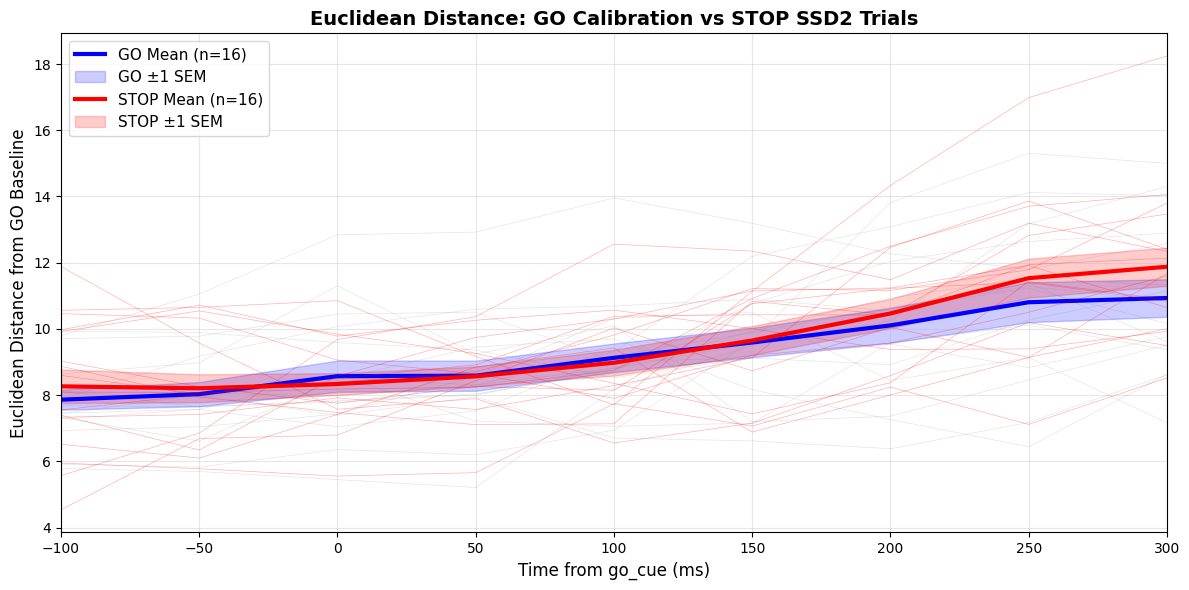


Euclidean Distance Statistics:
  - GO Mean distance (across all time): 9.292
  - GO Distance range (mean): 7.865 - 10.935
  - STOP Mean distance (across all time): 9.544
  - STOP Distance range (mean): 8.209 - 11.878


In [17]:
# Plot Euclidean distances across time with mean and error bars
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot all individual GO calibration trials in light gray
for i in range(euclidean_distances.shape[0]):
        ax.plot(go_binned['bin_centers'], euclidean_distances[i, :], 
                        color='gray', alpha=0.2, linewidth=0.5)

# Compute GO mean and SEM
euclidean_mean = euclidean_distances.mean(axis=0)
euclidean_sem = euclidean_distances.std(axis=0, ddof=1) / np.sqrt(euclidean_distances.shape[0])

# Plot GO mean with error bars
ax.plot(go_binned['bin_centers'], euclidean_mean, 
                color='blue', linewidth=3, label=f'GO Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
                                euclidean_mean - euclidean_sem, 
                                euclidean_mean + euclidean_sem,
                                color='blue', alpha=0.2, label='GO ±1 SEM')

# Plot all individual STOP trials in light red
for i in range(euclidean_distances_stop.shape[0]):
        ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                        euclidean_distances_stop[i, :], 
                        color='red', alpha=0.3, linewidth=0.5)

# Compute STOP mean and SEM
euclidean_mean_stop = euclidean_distances_stop.mean(axis=0)
euclidean_sem_stop = euclidean_distances_stop.std(axis=0, ddof=1) / np.sqrt(euclidean_distances_stop.shape[0])

# Plot STOP mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                euclidean_mean_stop, 
                color='red', linewidth=3, label=f'STOP Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
                                euclidean_mean_stop - euclidean_sem_stop, 
                                euclidean_mean_stop + euclidean_sem_stop,
                                color='red', alpha=0.2, label='STOP ±1 SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Euclidean Distance from GO Baseline', fontsize=12)
ax.set_title('Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
                         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nEuclidean Distance Statistics:")
print(f"  - GO Mean distance (across all time): {euclidean_mean.mean():.3f}")
print(f"  - GO Distance range (mean): {euclidean_mean.min():.3f} - {euclidean_mean.max():.3f}")
print(f"  - STOP Mean distance (across all time): {euclidean_mean_stop.mean():.3f}")
print(f"  - STOP Distance range (mean): {euclidean_mean_stop.min():.3f} - {euclidean_mean_stop.max():.3f}")

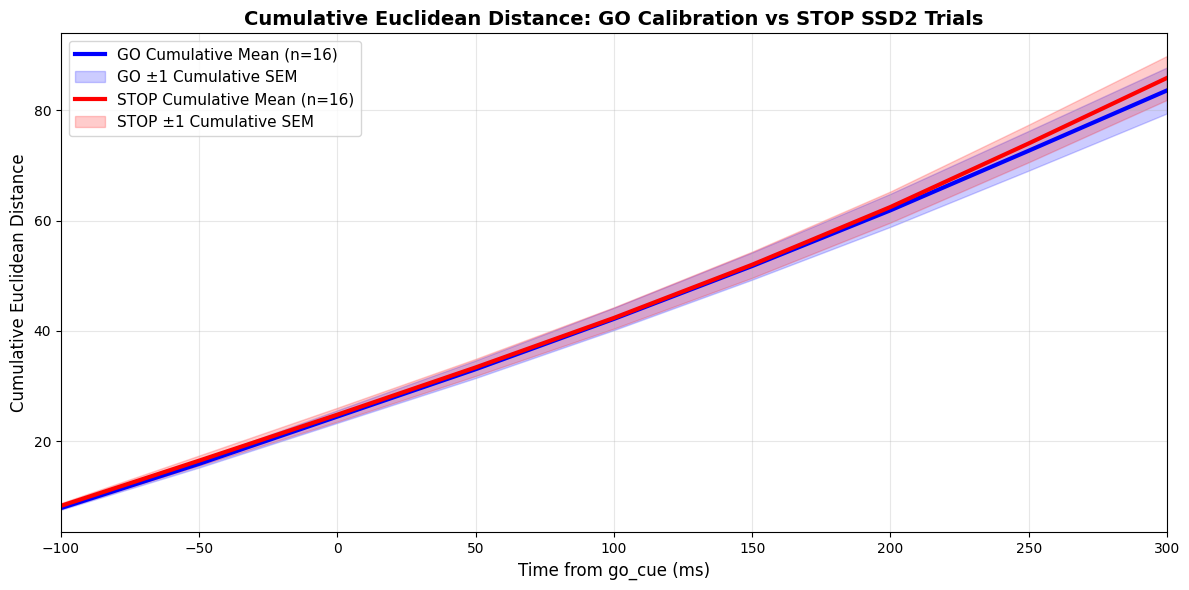


Cumulative Euclidean Distance Statistics:
  - GO Final cumulative distance: 83.6
  - STOP Final cumulative distance: 85.9
  - Difference at final time: 2.3


In [18]:
# Calculate cumulative sum of mean and std for GO and STOP distances
go_cumsum_mean = np.cumsum(euclidean_mean)
go_cumsum_std = np.cumsum(euclidean_sem)

stop_cumsum_mean = np.cumsum(euclidean_mean_stop)
stop_cumsum_std = np.cumsum(euclidean_sem_stop)

# Plot cumulative distances
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot GO cumulative mean with error bars
ax.plot(go_binned['bin_centers'], go_cumsum_mean, 
    color='blue', linewidth=3, label=f'GO Cumulative Mean (n={euclidean_distances.shape[0]})')
ax.fill_between(go_binned['bin_centers'], 
        go_cumsum_mean - go_cumsum_std, 
        go_cumsum_mean + go_cumsum_std,
        color='blue', alpha=0.2, label='GO ±1 Cumulative SEM')

# Plot STOP cumulative mean with error bars
ax.plot(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
    stop_cumsum_mean, 
    color='red', linewidth=3, label=f'STOP Cumulative Mean (n={euclidean_distances_stop.shape[0]})')
ax.fill_between(go_binned['bin_centers'][:euclidean_distances_stop.shape[1]], 
        stop_cumsum_mean - stop_cumsum_std, 
        stop_cumsum_mean + stop_cumsum_std,
        color='red', alpha=0.2, label='STOP ±1 Cumulative SEM')

ax.set_xlabel('Time from go_cue (ms)', fontsize=12)
ax.set_ylabel('Cumulative Euclidean Distance', fontsize=12)
ax.set_title('Cumulative Euclidean Distance: GO Calibration vs STOP SSD2 Trials', 
         fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(go_binned['bin_centers'][0], go_binned['bin_centers'][-1])

plt.tight_layout()
plt.show()

print(f"\nCumulative Euclidean Distance Statistics:")
print(f"  - GO Final cumulative distance: {go_cumsum_mean[-1]:.1f}")
print(f"  - STOP Final cumulative distance: {stop_cumsum_mean[-1]:.1f}")
print(f"  - Difference at final time: {stop_cumsum_mean[-1] - go_cumsum_mean[-1]:.1f}")